In [1]:
import itertools
import json
import math
import os
import sys
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import imageio.v2 as iio
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from skimage import io, measure
from skimage.color import rgb2gray, rgb2hed
from skimage.measure import label as cc_label
from skimage.segmentation import find_boundaries, relabel_sequential
from sklearn.metrics import matthews_corrcoef
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


/opt/conda/envs/cellseg_py36/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
WORK_DIR = Path("/data/work")

IMAGE_DIR = WORK_DIR / "Inference" / "Images"
MASK_DIR = WORK_DIR / "Inference" / "MaskInstance"
OUTPUT_ROOT = WORK_DIR / "Inference" / "CellSeg_Clean_GridSearch_V2"

# Kandidat lokasi repo CellSeg
CELLSEG_DIR_CANDIDATES = [
    WORK_DIR / "CellSeg-master",
    WORK_DIR / "CellSeg",
    Path.cwd() / "CellSeg-master",
    Path.cwd() / "CellSeg",
]

# Jika None, notebook akan memakai pasangan pertama setelah sorting nama file
TUNING_IMAGE_STEM = None

# Preprocessing input untuk H&E
SEGMENT_INPUT_MODE = "hed"   # rekomendasi untuk H&E
USE_GPU = True

# Parameter tetap / default notebook
BOOST_FIXED = 0.0
OVERLAP_FIXED = 80

# Grid default utama (aktif)
INCREASE_FACTOR_GRID = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
MIN_CONFIDENCE_GRID = [0.3, 0.5, 0.7, 0.9]
MIN_AREA_GRID_COUNT = 4
MIN_AREA_GRID_MIN_FLOOR = 5

# Opsi advanced grid (matikan default agar kombinasi tidak meledak)
ENABLE_BOOST_GRID = False
BOOST_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]

ENABLE_OVERLAP_GRID = False
OVERLAP_GRID = [40, 80, 120]

# Threshold object-level F1 yang dicatat
F1_THRESHOLDS = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]

# Output
GRID_DIR = OUTPUT_ROOT / "01_grid_search"
PER_IMAGE_DIR = OUTPUT_ROOT / "02_hasil_inferensi_per_gambar"
SUMMARY_DIR = OUTPUT_ROOT / "03_ringkasan_rata_rata_metrik"

for folder in [OUTPUT_ROOT, GRID_DIR, PER_IMAGE_DIR, SUMMARY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_CONFIG_PATH = OUTPUT_ROOT / "run_config.json"
MODEL_INFO_PATH = OUTPUT_ROOT / "model_resolution_info.json"

def resolve_existing_path(candidates, what):
    existing = [Path(p) for p in candidates if p is not None and Path(p).exists()]
    if existing:
        return existing[0]
    raise FileNotFoundError(
        "{} tidak ditemukan. Kandidat yang dicek:\n{}".format(
            what,
            "\n".join([str(Path(p)) for p in candidates if p is not None])
        )
    )

CELLSEG_DIR = resolve_existing_path(CELLSEG_DIR_CANDIDATES, "Folder repo CellSeg")
MODEL_PATH = CELLSEG_DIR / "src" / "modelFiles" / "final_weights.h5"

if not MODEL_PATH.exists():
    raise FileNotFoundError("Weights CellSeg tidak ditemukan: {}".format(MODEL_PATH))

print("IMAGE_DIR   :", IMAGE_DIR)
print("MASK_DIR    :", MASK_DIR)
print("CELLSEG_DIR :", CELLSEG_DIR)
print("MODEL_PATH  :", MODEL_PATH)
print("OUTPUT_ROOT :", OUTPUT_ROOT)


IMAGE_DIR   : /data/work/Inference/Images
MASK_DIR    : /data/work/Inference/MaskInstance
CELLSEG_DIR : /data/work/CellSeg-master
MODEL_PATH  : /data/work/CellSeg-master/src/modelFiles/final_weights.h5
OUTPUT_ROOT : /data/work/Inference/CellSeg_Clean_GridSearch_V2


In [3]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def build_stem_index(folder, valid_exts):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError("Folder tidak ditemukan: {}".format(folder))
    idx = {}
    for fp in sorted(folder.iterdir()):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in valid_exts:
            continue
        idx[fp.stem] = fp
    return idx

def pair_image_and_mask_files(image_dir, mask_dir):
    image_idx = build_stem_index(image_dir, IMAGE_EXTS)
    mask_idx = build_stem_index(mask_dir, MASK_EXTS)

    common = sorted(set(image_idx) & set(mask_idx))
    missing_images = sorted(set(mask_idx) - set(image_idx))
    missing_masks = sorted(set(image_idx) - set(mask_idx))

    if missing_images:
        print("⚠ Mask ada tetapi image tidak ada ({}): {}".format(len(missing_images), missing_images[:5]))
    if missing_masks:
        print("⚠ Image ada tetapi mask tidak ada ({}): {}".format(len(missing_masks), missing_masks[:5]))

    if not common:
        raise RuntimeError("Tidak ada pasangan image-mask yang cocok berdasarkan stem filename.")

    pairs = []
    for stem in common:
        pairs.append({
            "stem": stem,
            "image_path": image_idx[stem],
            "mask_path": mask_idx[stem],
        })
    return pairs

def _standardize_hw_c(img):
    arr = np.asarray(img)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        if arr.shape[0] in (1, 3, 4) and arr.shape[-1] not in (1, 3, 4):
            return np.transpose(arr, (1, 2, 0))
        return arr
    if arr.ndim == 4:
        return _standardize_hw_c(arr[0])
    raise ValueError("Dimensi tidak didukung: {}".format(arr.shape))

def read_image_any(path, prefer_memmap=False):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix in (".tif", ".tiff"):
        if prefer_memmap:
            try:
                mm = tifffile.memmap(str(path))
                return _standardize_hw_c(mm)
            except Exception:
                pass
        return _standardize_hw_c(tifffile.imread(str(path)))
    arr = io.imread(str(path))
    return _standardize_hw_c(arr)

def to_float01(img):
    x = np.asarray(img).astype(np.float32)
    if x.size == 0:
        return x
    if x.max() > 1.5:
        denom = 255.0 if x.max() <= 255.0 else 65535.0
        x = x / denom
    return np.clip(x, 0.0, 1.0)

def to_uint8(img, p_low=1.0, p_high=99.0):
    x = np.asarray(img).astype(np.float32)
    lo, hi = np.percentile(x, [p_low, p_high])
    if hi <= lo:
        lo, hi = float(x.min()), float(x.max())
        if hi <= lo:
            hi = lo + 1.0
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)
    return (x * 255).astype(np.uint8)

def ensure_rgb_u8(img):
    arr = _standardize_hw_c(img)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    if arr.ndim == 3 and arr.shape[2] == 4:
        arr = arr[..., :3]
    if arr.dtype != np.uint8:
        arr = to_uint8(arr)
    if arr.ndim == 3 and arr.shape[2] == 1:
        arr = np.repeat(arr, 3, axis=2)
    if not (arr.ndim == 3 and arr.shape[2] == 3):
        raise ValueError("Image harus RGB 3-channel, tetapi shape = {}".format(arr.shape))
    return arr

def load_instance_mask(path):
    arr = read_image_any(path, prefer_memmap=False)
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = np.asarray(arr)
    if not np.issubdtype(arr.dtype, np.integer):
        arr = np.rint(arr).astype(np.int32)
    arr = relabel_sequential(arr.astype(np.int32))[0]
    return arr.astype(np.int32)

def to_binary(mask):
    return (np.asarray(mask) > 0).astype(np.uint8)

def normalize_for_display(img):
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    arr = arr.astype(np.float32)
    if arr.size == 0:
        return arr
    arr = arr - arr.min()
    denom = arr.max() + 1e-8
    if denom > 0:
        arr = arr / denom
    return arr

def save_binary_png(path, mask_bin):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(path), (to_binary(mask_bin) * 255).astype(np.uint8), check_contrast=False)

def get_instance_areas(label_img):
    lab = np.asarray(label_img).astype(np.int64)
    if lab.size == 0:
        return np.zeros((0,), dtype=np.int64)
    m = int(lab.max())
    if m <= 0:
        return np.zeros((0,), dtype=np.int64)
    areas = np.bincount(lab.ravel(), minlength=m + 1).astype(np.int64)
    return areas[1:]

def auto_min_area_grid(gt_label_img, n=4, min_floor=5):
    areas = get_instance_areas(gt_label_img)
    if areas.size == 0:
        base = [5, 10, 20, 40, 80, 160, 320, 640]
        return base[:n]

    ps = np.linspace(1.0, 40.0, max(n, 2))
    vals = np.percentile(areas, ps)
    grid = sorted({int(max(min_floor, round(v))) for v in vals})

    if len(grid) < n:
        a_min = max(min_floor, int(np.percentile(areas, 1)))
        a_max = max(a_min + 1, int(np.percentile(areas, 60)))
        geo = np.geomspace(a_min, a_max, n)
        grid = sorted({int(max(min_floor, round(v))) for v in geo})

    while len(grid) < n:
        grid.append(grid[-1] + 1)

    return grid[:n]

def safe_tiff_write(path, array, compression="zlib"):
    path = Path(path)
    arr = np.ascontiguousarray(np.asarray(array))

    try:
        if hasattr(tifffile, "imwrite"):
            try:
                tifffile.imwrite(str(path), arr, compression=compression)
            except TypeError:
                tifffile.imwrite(str(path), arr)
            return str(path)
    except Exception as exc:
        last_err = exc
    else:
        last_err = None

    try:
        if hasattr(tifffile, "imsave"):
            tifffile.imsave(str(path), arr)
            return str(path)
    except Exception as exc:
        last_err = exc

    npy_path = path.with_suffix(".npy")
    np.save(str(npy_path), arr)
    print("[WARN] Gagal menulis TIFF ke {}. Disimpan sebagai {}. Error terakhir: {}".format(path, npy_path, last_err))
    return str(npy_path)

pairs = pair_image_and_mask_files(IMAGE_DIR, MASK_DIR)
pairs_df = pd.DataFrame([
    {
        "stem": p["stem"],
        "image_path": str(p["image_path"]),
        "mask_path": str(p["mask_path"]),
    }
    for p in pairs
]).sort_values("stem").reset_index(drop=True)

display(pairs_df.head())
print("Jumlah pasangan cocok:", len(pairs_df))

pairs_df.to_csv(OUTPUT_ROOT / "paired_input_files.csv", index=False)
print("File pairing tersimpan di:", OUTPUT_ROOT / "paired_input_files.csv")


,stem,image_path,mask_path
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...


Jumlah pasangan cocok: 30
File pairing tersimpan di: /data/work/Inference/CellSeg_Clean_GridSearch_V2/paired_input_files.csv


## Evaluasi — terintegrasi dengan `Evaluasi.py`

Notebook ini **mencoba mengimpor `Evaluasi.py` eksternal** terlebih dahulu agar rumus metrik tetap konsisten dengan file evaluasi yang Anda berikan.  
Jika file tersebut tidak ditemukan, notebook akan otomatis memakai **fallback internal** yang disalin / diadaptasi dari `Evaluasi.py`, sehingga notebook tetap self-contained dan tetap bisa dijalankan.


In [4]:
import ast
import types

def load_evaluasi_namespace_safely(py_path):
    py_path = Path(py_path)
    source = py_path.read_text(encoding="utf-8")
    tree = ast.parse(source, filename=str(py_path))

    safe_nodes = []
    for node in tree.body:
        if isinstance(node, (ast.Import, ast.ImportFrom, ast.FunctionDef, ast.ClassDef)):
            safe_nodes.append(node)

    try:
        module_ast = ast.Module(body=safe_nodes, type_ignores=[])
    except TypeError:
        module_ast = ast.Module(safe_nodes)

    namespace = {}
    exec(compile(module_ast, str(py_path), "exec"), namespace, namespace)
    return types.SimpleNamespace(**namespace)

EVALUASI_PY_CANDIDATES = [
    OUTPUT_ROOT.parent / "Evaluasi.py",
    WORK_DIR / "Evaluasi.py",
    Path.cwd() / "Evaluasi.py",
    Path("/mnt/data/Evaluasi.py"),
]

EVAL_MODULE = None
EVAL_MODULE_PATH = None

for cand in EVALUASI_PY_CANDIDATES:
    cand = Path(cand)
    if cand.exists() and cand.is_file():
        EVAL_MODULE = load_evaluasi_namespace_safely(cand)
        EVAL_MODULE_PATH = cand
        break

if EVAL_MODULE is not None:
    print("Menggunakan fungsi-fungsi dari Evaluasi.py:", EVAL_MODULE_PATH)
else:
    print("Evaluasi.py eksternal tidak ditemukan. Menggunakan fallback internal yang diadaptasi dari Evaluasi.py.")

def safe_mcc(y_true, y_pred):
    try:
        return float(matthews_corrcoef(y_true.astype(int), y_pred.astype(int)))
    except Exception:
        return 0.0

if EVAL_MODULE is not None:
    # Alias langsung ke fungsi-fungsi utama dari Evaluasi.py
    compute_iou_matrix = EVAL_MODULE.compute_iou_matrix
    match_instances = EVAL_MODULE.match_instances
    _pixel_metrics_external = EVAL_MODULE.pixel_metrics
    _compute_aji_external = EVAL_MODULE.compute_aji
    _compute_pq_external = EVAL_MODULE.compute_pq
    _object_f1_external = EVAL_MODULE.object_f1_at_thresholds
    _count_metrics_external = EVAL_MODULE.count_metrics
    _morphology_stats_external = EVAL_MODULE.morphology_stats

    def pixel_metrics(gt_bin, pred_bin):
        return _pixel_metrics_external(to_binary(gt_bin), to_binary(pred_bin))

    def compute_aji(gt_inst, pred_inst):
        return _compute_aji_external(gt_inst, pred_inst)

    def compute_pq(gt_inst, pred_inst, iou_threshold=0.5):
        res = _compute_pq_external(gt_inst, pred_inst, iou_threshold=iou_threshold)
        if "TP" in res:
            res["TP_objects"] = int(res.pop("TP"))
        if "FP" in res:
            res["FP_objects"] = int(res.pop("FP"))
        if "FN" in res:
            res["FN_objects"] = int(res.pop("FN"))
        return res

    def object_f1_at_thresholds(gt_inst, pred_inst, thresholds=(0.3, 0.5, 0.6, 0.7, 0.8, 0.9)):
        return _object_f1_external(gt_inst, pred_inst, thresholds=thresholds)

    def count_metrics(gt_inst, pred_inst, iou_threshold=0.5):
        return _count_metrics_external(gt_inst, pred_inst, iou_threshold=iou_threshold)

    def morphology_stats(instance_mask, prefix=""):
        return _morphology_stats_external(instance_mask, prefix=prefix)

else:
    # Fallback internal (diadaptasi dari Evaluasi.py)
    def pixel_metrics(gt_bin, pred_bin):
        gt = np.asarray(gt_bin).flatten().astype(bool)
        pred = np.asarray(pred_bin).flatten().astype(bool)

        TP = np.logical_and(pred, gt).sum()
        FP = np.logical_and(pred, np.logical_not(gt)).sum()
        FN = np.logical_and(np.logical_not(pred), gt).sum()
        TN = np.logical_and(np.logical_not(pred), np.logical_not(gt)).sum()

        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        iou = TP / (TP + FP + FN + 1e-8)
        dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
        specificity = TN / (TN + FP + 1e-8)
        mcc = safe_mcc(gt.astype(int), pred.astype(int))

        return {
            "Precision": round(float(precision), 6),
            "Recall": round(float(recall), 6),
            "F1": round(float(f1), 6),
            "IoU": round(float(iou), 6),
            "Dice": round(float(dice), 6),
            "Specificity": round(float(specificity), 6),
            "MCC": round(float(mcc), 6),
            "TP_pixels": int(TP),
            "FP_pixels": int(FP),
            "FN_pixels": int(FN),
            "TN_pixels": int(TN),
        }

    def compute_iou_matrix(gt_inst, pred_inst):
        gt_ids = np.unique(gt_inst[gt_inst > 0])
        pred_ids = np.unique(pred_inst[pred_inst > 0])
        iou_matrix = np.zeros((len(gt_ids), len(pred_ids)), dtype=np.float32)

        for i, gid in enumerate(gt_ids):
            gt_mask = (gt_inst == gid)
            for j, pid in enumerate(pred_ids):
                pred_mask = (pred_inst == pid)
                intersection = np.logical_and(gt_mask, pred_mask).sum()
                if intersection == 0:
                    continue
                union = np.logical_or(gt_mask, pred_mask).sum()
                iou_matrix[i, j] = intersection / (union + 1e-8)

        return gt_ids, pred_ids, iou_matrix

    def match_instances(gt_inst, pred_inst, iou_threshold=0.5):
        gt_ids, pred_ids, iou_matrix = compute_iou_matrix(gt_inst, pred_inst)

        if iou_matrix.size == 0:
            return [], list(gt_ids), list(pred_ids)

        row_ind, col_ind = linear_sum_assignment(-iou_matrix)

        matched_pairs = []
        unmatched_gt = set(range(len(gt_ids)))
        unmatched_pred = set(range(len(pred_ids)))

        for r, c in zip(row_ind, col_ind):
            if iou_matrix[r, c] >= iou_threshold:
                matched_pairs.append((int(gt_ids[r]), int(pred_ids[c]), float(iou_matrix[r, c])))
                unmatched_gt.discard(r)
                unmatched_pred.discard(c)

        unmatched_gt = [int(gt_ids[i]) for i in unmatched_gt]
        unmatched_pred = [int(pred_ids[i]) for i in unmatched_pred]
        return matched_pairs, unmatched_gt, unmatched_pred

    def compute_aji(gt_inst, pred_inst):
        gt_ids = np.unique(gt_inst[gt_inst > 0])
        pred_ids = np.unique(pred_inst[pred_inst > 0])

        if len(gt_ids) == 0:
            return 0.0

        total_intersection = 0
        total_union = 0
        used_pred = set()

        for gid in gt_ids:
            gt_mask = (gt_inst == gid)
            best_iou = 0.0
            best_pid = None

            for pid in pred_ids:
                pred_mask = (pred_inst == pid)
                intersection = np.logical_and(gt_mask, pred_mask).sum()
                if intersection == 0:
                    continue
                union = np.logical_or(gt_mask, pred_mask).sum()
                iou = intersection / (union + 1e-8)
                if iou > best_iou:
                    best_iou = iou
                    best_pid = pid

            if best_pid is not None:
                used_pred.add(best_pid)
                pred_mask = (pred_inst == best_pid)
                total_intersection += np.logical_and(gt_mask, pred_mask).sum()
                total_union += np.logical_or(gt_mask, pred_mask).sum()
            else:
                total_union += gt_mask.sum()

        for pid in pred_ids:
            if pid not in used_pred:
                total_union += (pred_inst == pid).sum()

        return round(float(total_intersection) / (float(total_union) + 1e-8), 6)

    def compute_pq(gt_inst, pred_inst, iou_threshold=0.5):
        matched_pairs, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=iou_threshold)

        TP = len(matched_pairs)
        FP = len(unmatched_pred)
        FN = len(unmatched_gt)

        dq = TP / (TP + 0.5 * FP + 0.5 * FN + 1e-8)
        sq = float(np.mean([p[2] for p in matched_pairs])) if TP > 0 else 0.0
        pq = dq * sq

        return {
            "PQ": round(float(pq), 6),
            "DQ": round(float(dq), 6),
            "SQ": round(float(sq), 6),
            "TP_objects": int(TP),
            "FP_objects": int(FP),
            "FN_objects": int(FN),
        }

    def object_f1_at_thresholds(gt_inst, pred_inst, thresholds=(0.3, 0.5, 0.6, 0.7, 0.8, 0.9)):
        results = {}
        for t in thresholds:
            matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, float(t))
            TP = len(matched)
            FP = len(unmatched_pred)
            FN = len(unmatched_gt)
            precision = TP / (TP + FP + 1e-8)
            recall = TP / (TP + FN + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            results["F1@{}".format(t)] = round(float(f1), 6)
        return results

    def count_metrics(gt_inst, pred_inst, iou_threshold=0.5):
        n_gt = int(len(np.unique(gt_inst[gt_inst > 0])))
        n_pred = int(len(np.unique(pred_inst[pred_inst > 0])))
        matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=iou_threshold)

        count_err = n_pred - n_gt
        rel_count_err = count_err / (n_gt + 1e-8)
        over_seg = len(unmatched_pred) / (n_gt + 1e-8)
        under_seg = len(unmatched_gt) / (n_gt + 1e-8)

        return {
            "N_GT": n_gt,
            "N_Pred": n_pred,
            "Count_Error": int(count_err),
            "Abs_Count_Error": int(abs(count_err)),
            "Rel_Count_Err": round(float(rel_count_err), 6),
            "Over_Seg_Rate": round(float(over_seg), 6),
            "Under_Seg_Rate": round(float(under_seg), 6),
        }

    def morphology_stats(instance_mask, prefix=""):
        props = measure.regionprops(instance_mask)
        if not props:
            return {}

        areas = [float(p.area) for p in props]
        circs = [
            float(4 * np.pi * p.area / (p.perimeter ** 2 + 1e-8))
            for p in props if p.perimeter > 0
        ]
        eccs = [float(p.eccentricity) for p in props]
        diams = [float(p.equivalent_diameter) for p in props]

        return {
            "{}Area_Mean".format(prefix): round(float(np.mean(areas)), 6),
            "{}Area_Std".format(prefix): round(float(np.std(areas)), 6),
            "{}Area_Med".format(prefix): round(float(np.median(areas)), 6),
            "{}Circ_Mean".format(prefix): round(float(np.mean(circs)) if circs else 0.0, 6),
            "{}Ecc_Mean".format(prefix): round(float(np.mean(eccs)), 6),
            "{}Diam_Mean".format(prefix): round(float(np.mean(diams)), 6),
        }

def evaluate_case(gt_inst, pred_inst, thresholds=F1_THRESHOLDS):
    gt_inst = relabel_sequential(gt_inst.astype(np.int32))[0]
    pred_inst = relabel_sequential(pred_inst.astype(np.int32))[0]

    gt_bin = to_binary(gt_inst)
    pred_bin = to_binary(pred_inst)

    row = {}
    row.update(pixel_metrics(gt_bin, pred_bin))
    row["AJI"] = compute_aji(gt_inst, pred_inst)
    row.update(compute_pq(gt_inst, pred_inst, iou_threshold=0.5))
    row.update(count_metrics(gt_inst, pred_inst, iou_threshold=0.5))
    row.update(object_f1_at_thresholds(gt_inst, pred_inst, thresholds=thresholds))
    row.update(morphology_stats(gt_inst, prefix="GT_"))
    row.update(morphology_stats(pred_inst, prefix="Pred_"))

    for metric_name in ["Area_Mean", "Area_Std", "Area_Med", "Circ_Mean", "Ecc_Mean", "Diam_Mean"]:
        gt_key = "GT_{}".format(metric_name)
        pred_key = "Pred_{}".format(metric_name)
        if gt_key in row and pred_key in row:
            row["AbsDiff_{}".format(metric_name)] = round(abs(float(row[pred_key]) - float(row[gt_key])), 6)

    row["Primary_Score_Mean"] = round(
        float(np.mean([row["Precision"], row["Recall"], row["F1"], row["IoU"]])),
        6,
    )
    return row


Evaluasi.py eksternal tidak ditemukan. Menggunakan fallback internal yang diadaptasi dari Evaluasi.py.


In [5]:
def create_overlay_image(image, gt_inst, pred_inst):
    base = normalize_for_display(image).copy()
    gt_boundary = find_boundaries(gt_inst, mode="outer")
    pred_boundary = find_boundaries(pred_inst, mode="outer")
    base[gt_boundary] = [0.0, 1.0, 0.0]
    base[pred_boundary] = [1.0, 0.3, 0.0]
    return base

def create_error_map(gt_inst, pred_inst, iou_threshold=0.5):
    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=iou_threshold)
    h, w = gt_inst.shape
    error_map = np.zeros((h, w, 3), dtype=np.float32)

    for _, pid, _ in matched:
        error_map[pred_inst == pid] = [0.1, 0.8, 0.1]
    for pid in unmatched_pred:
        error_map[pred_inst == pid] = [0.9, 0.1, 0.1]
    for gid in unmatched_gt:
        error_map[gt_inst == gid] = [0.1, 0.3, 0.9]

    return error_map

def save_case_visuals(image, gt_inst, pred_inst, output_dir, stem):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    overlay = create_overlay_image(image, gt_inst, pred_inst)
    error_map = create_error_map(gt_inst, pred_inst)

    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=0.5)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    axes[0].imshow(normalize_for_display(image))
    axes[0].set_title("Original")
    axes[1].imshow(gt_inst, cmap="nipy_spectral")
    axes[1].set_title("GT Instance")
    axes[2].imshow(pred_inst, cmap="nipy_spectral")
    axes[2].set_title("Pred Instance")
    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[4].imshow(error_map)
    axes[4].set_title(
        "Error Map\nTP={} | FP={} | FN={}".format(len(matched), len(unmatched_pred), len(unmatched_gt))
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(output_dir / "{}_panel.png".format(stem), dpi=150, bbox_inches="tight")
    plt.close(fig)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / "{}_overlay.png".format(stem), dpi=150, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(6, 6))
    plt.imshow(error_map)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / "{}_error_map.png".format(stem), dpi=150, bbox_inches="tight")
    plt.close()

def _json_default(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    raise TypeError("Type not serializable: {}".format(type(obj)))

def save_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False, default=_json_default)

def plot_metric_boxplots(metrics_df, output_path):
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    plt.figure(figsize=(12, 5))
    metrics_df[cols].boxplot(rot=30)
    plt.ylabel("Skor")
    plt.title("Distribusi metrik per gambar")
    plt.tight_layout()
    plt.savefig(str(output_path), dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_means(metrics_df, output_path):
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    means = metrics_df[cols].mean()
    stds = metrics_df[cols].std(ddof=1).fillna(0)
    plt.figure(figsize=(12, 5))
    plt.bar(cols, means.values, yerr=stds.values, capsize=4)
    plt.xticks(rotation=30)
    plt.ylabel("Mean ± SD")
    plt.title("Rata-rata performa model pada seluruh gambar")
    plt.tight_layout()
    plt.savefig(str(output_path), dpi=150, bbox_inches="tight")
    plt.close()

def plot_object_f1_curve(metrics_df, output_path):
    threshold_cols = [c for c in metrics_df.columns if c.startswith("F1@")]
    if not threshold_cols:
        return
    threshold_cols = sorted(threshold_cols, key=lambda x: float(x.split("@")[1]))
    xs = [float(c.split("@")[1]) for c in threshold_cols]
    ys = metrics_df[threshold_cols].mean().values
    yerr = metrics_df[threshold_cols].std(ddof=1).fillna(0).values

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o")
    plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2)
    plt.ylim(0, 1.05)
    plt.xticks(xs)
    plt.xlabel("IoU threshold")
    plt.ylabel("Object-level F1")
    plt.title("Object-level F1 terhadap IoU threshold")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(output_path), dpi=150, bbox_inches="tight")
    plt.close()

def plot_cell_count_scatter(metrics_df, output_path):
    required = {"N_GT", "N_Pred"}
    if not required.issubset(set(metrics_df.columns)):
        return
    max_val = float(max(metrics_df["N_GT"].max(), metrics_df["N_Pred"].max(), 1))
    plt.figure(figsize=(6, 6))
    plt.scatter(metrics_df["N_GT"], metrics_df["N_Pred"], alpha=0.8)
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Jumlah sel GT")
    plt.ylabel("Jumlah sel prediksi")
    plt.title("Cell count comparison per gambar")
    plt.tight_layout()
    plt.savefig(str(output_path), dpi=150, bbox_inches="tight")
    plt.close()

def plot_morphology_summary(metrics_df, output_path):
    candidate_pairs = [
        ("GT_Area_Mean", "Pred_Area_Mean"),
        ("GT_Circ_Mean", "Pred_Circ_Mean"),
        ("GT_Diam_Mean", "Pred_Diam_Mean"),
    ]
    available_pairs = [pair for pair in candidate_pairs if pair[0] in metrics_df.columns and pair[1] in metrics_df.columns]
    if not available_pairs:
        return

    fig, axes = plt.subplots(1, len(available_pairs), figsize=(6 * len(available_pairs), 5))
    if len(available_pairs) == 1:
        axes = [axes]

    for ax, pair in zip(axes, available_pairs):
        gt_col, pred_col = pair
        ax.boxplot([metrics_df[gt_col].dropna(), metrics_df[pred_col].dropna()], labels=["GT", "Pred"])
        ax.set_title(gt_col.replace("GT_", "").replace("_", " "))
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(str(output_path), dpi=150, bbox_inches="tight")
    plt.close()


In [6]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

if str(CELLSEG_DIR) not in sys.path:
    sys.path.insert(0, str(CELLSEG_DIR))

import tensorflow as tf
import keras
from keras import backend as K

try:
    gpus = tf.config.list_physical_devices("GPU")
except Exception:
    gpus = []

if USE_GPU:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as exc:
        print("GPU config warning:", exc)

from src.cvstitch import CVMaskStitcher
import src.cvmodel as modellib
from src.cvmodelconfig import CVSegmentationConfig

model_info = {
    "cellseg_repo_dir": str(CELLSEG_DIR),
    "model_path": str(MODEL_PATH),
    "tensorflow_version": getattr(tf, "__version__", None),
    "keras_version": getattr(keras, "__version__", None),
    "gpu_requested": bool(USE_GPU),
    "gpu_devices": [str(g) for g in gpus],
    "segment_input_mode": SEGMENT_INPUT_MODE,
    "official_tunable_parameters": {
        "BOOST": {
            "source": "CellSeg tutorial",
            "note": "brightness multiplier; 0.0 menonaktifkan boost"
        },
        "OVERLAP": {
            "source": "CellSeg tutorial",
            "default_recommendation": 80
        },
        "THRESHOLD": {
            "source": "CellSeg tutorial",
            "note": "minimum object size; dipakai sebagai min_area"
        },
        "INCREASE_FACTOR": {
            "source": "CellSeg tutorial / cvconfig.py",
            "default": 2.5
        },
        "DETECTION_MIN_CONFIDENCE": {
            "source": "src/cvmodelconfig.py",
            "default": 0.8
        },
        "AUTOBOOST_PERCENTILE": {
            "source": "cvconfig.py",
            "default": 99.98
        },
        "GROWTH_PIXELS": {
            "source": "CellSeg tutorial",
            "default": 0
        },
        "GROWTH_METHOD": {
            "source": "CellSeg tutorial",
            "default": "Standard"
        }
    }
}

save_json(MODEL_INFO_PATH, model_info)

print("TensorFlow :", model_info["tensorflow_version"])
print("Keras      :", model_info["keras_version"])
print("GPU aktif  :", model_info["gpu_devices"])
print("CellSeg OK :", CELLSEG_DIR)


TensorFlow : 1.14.0
Keras      : 2.2.4
GPU aktif  : []
CellSeg OK : /data/work/CellSeg-master


Using TensorFlow backend.


In [7]:
def apply_boost_u8(img_u8, boost):
    if boost is None:
        return img_u8
    boost = float(boost)
    if boost == 0.0:
        return img_u8
    factor = 1.0 + boost
    x = img_u8.astype(np.float32) * factor
    return np.clip(x, 0, 255).astype(np.uint8)

def he_hematoxylin_u8(rgb_u8):
    rgb01 = to_float01(ensure_rgb_u8(rgb_u8))
    hed = rgb2hed(rgb01)
    h = hed[..., 0]
    return to_uint8(h)

def prepare_segment_input(rgb_u8, mode="hed", boost=0.0):
    rgb_u8 = ensure_rgb_u8(rgb_u8)
    dbg = {"rgb_u8": rgb_u8}

    if mode == "rgb":
        seg = rgb_u8
    elif mode == "hed":
        nuc = he_hematoxylin_u8(rgb_u8)
        dbg["nuclear_u8"] = nuc
        seg = np.stack([nuc, nuc, nuc], axis=-1)
    elif mode == "gray":
        g = (rgb2gray(to_float01(rgb_u8)) * 255).astype(np.uint8)
        dbg["gray_u8"] = g
        seg = np.stack([g, g, g], axis=-1)
    else:
        raise ValueError("mode tidak dikenal: {}".format(mode))

    seg = ensure_rgb_u8(seg)
    seg = apply_boost_u8(seg, boost)
    dbg["seg_u8"] = seg
    return seg, dbg

def remove_small_instances(label_img, min_area):
    lab = label_img.astype(np.int32, copy=True)
    if min_area <= 0:
        return relabel_sequential(lab)[0].astype(np.int32)
    ids, counts = np.unique(lab, return_counts=True)
    for _id, cnt in zip(ids, counts):
        if _id == 0:
            continue
        if cnt < min_area:
            lab[lab == _id] = 0
    lab = relabel_sequential(lab)[0]
    return lab.astype(np.int32)

AUTOSIZE_MAX_SIZE = 800
IMAGE_GRID = {
    (9072, 9408): (14, 14),
    (1440, 1344): (2, 2),
    (1440, 1920): (2, 2),
    (1008, 1344): (1, 2),
    (1008, 1920): (1, 2),
    (504, 672): (1, 1),
}

import contextlib

@contextlib.contextmanager
def _suppress_matplotlib_show():
    old_show = plt.show
    try:
        plt.show = lambda *args, **kwargs: None
        yield
    finally:
        plt.show = old_show

def _compute_grid(shape_hw):
    if tuple(shape_hw) in IMAGE_GRID:
        return IMAGE_GRID[tuple(shape_hw)]
    h, w = shape_hw
    return int(np.ceil(float(h) / AUTOSIZE_MAX_SIZE)), int(np.ceil(float(w) / AUTOSIZE_MAX_SIZE))

def _get_overlap_coordinates(rows, cols, i, j, x1, x2, y1, y2, overlap):
    half = overlap // 2
    if i != 0:
        y1 -= half
    if i != rows - 1:
        y2 += half
    if j != 0:
        x1 -= half
    if j != cols - 1:
        x2 += half
    return x1, x2, y1, y2

def _crop_with_overlap(arr, nrows, ncols, overlap):
    crop_height = arr.shape[0] // nrows
    crop_width = arr.shape[1] // ncols
    crops = []
    for row in range(nrows):
        for col in range(ncols):
            x1, y1 = col * crop_width, row * crop_height
            x2, y2 = (col + 1) * crop_width, (row + 1) * crop_height
            x1, x2, y1, y2 = _get_overlap_coordinates(nrows, ncols, row, col, x1, x2, y1, y2, overlap)
            crops.append(arr[y1:y2, x1:x2, :])
    return crops

def build_cellseg_model(image_shape_hw3, model_path, overlap, increase_factor, min_confidence):
    K.clear_session()

    h, w, _ = image_shape_hw3
    nrows, ncols = _compute_grid((h, w))
    smallest_side = min(h // nrows, w // ncols) + int(overlap)

    config = CVSegmentationConfig(
        smallest_side=smallest_side,
        increase_factor=float(increase_factor),
        min_confidence=float(min_confidence),
    )

    model = modellib.MaskRCNN(mode="inference", config=config)
    model.load_weights(str(model_path), by_name=True)
    return model, nrows, ncols, config

def infer_cellseg_crops(model, seg_input_u8, nrows, ncols, overlap):
    crops = _crop_with_overlap(seg_input_u8, nrows, ncols, overlap)
    crop_label_maps = []
    crop_scores = []

    for crop in crops:
        res = model.detect([crop], verbose=0)[0]
        masks = res.get("masks")
        scores = res.get("scores")

        if masks is None or masks.ndim != 3 or masks.shape[2] == 0:
            h, w = crop.shape[:2]
            crop_label_maps.append(np.zeros((h, w), dtype=np.int32))
            crop_scores.append(np.zeros((0,), dtype=np.float32))
        else:
            kk = masks.shape[2]
            lab = np.max(
                np.arange(1, kk + 1, dtype=np.int32)[None, None, :] * masks.astype(np.int32),
                axis=2
            )
            crop_label_maps.append(lab.astype(np.int32))
            crop_scores.append(np.asarray(scores, dtype=np.float32))

    return crop_label_maps, crop_scores

def stitch_crops_to_full_label(crop_label_maps, nrows, ncols, overlap, min_area, quiet=True):
    if len(crop_label_maps) == 1:
        full = crop_label_maps[0]
        return remove_small_instances(full, min_area=min_area)

    stitcher = CVMaskStitcher(overlap=int(overlap), threshold=int(min_area))
    if quiet:
        with _suppress_matplotlib_show():
            full = stitcher.stitch_masks(crop_label_maps, nrows, ncols)
    else:
        full = stitcher.stitch_masks(crop_label_maps, nrows, ncols)
    full = np.asarray(full).astype(np.int32)
    full = remove_small_instances(full, min_area=min_area)
    return full

def run_cellseg_once(img_rgb_u8, mode, boost, overlap, increase_factor, min_confidence, min_area):
    seg_input_u8, dbg = prepare_segment_input(img_rgb_u8, mode=mode, boost=boost)
    model, nrows, ncols, cfg = build_cellseg_model(
        seg_input_u8.shape,
        MODEL_PATH,
        overlap,
        increase_factor,
        min_confidence,
    )
    crop_labs, crop_scores = infer_cellseg_crops(model, seg_input_u8, nrows, ncols, overlap)
    full_label = stitch_crops_to_full_label(
        crop_labs,
        nrows,
        ncols,
        overlap,
        min_area=min_area,
        quiet=True,
    )
    pred_scores = crop_scores[0] if len(crop_scores) == 1 else None

    return {
        "seg_input_u8": seg_input_u8,
        "full_label": relabel_sequential(full_label.astype(np.int32))[0].astype(np.int32),
        "pred_bin_u8": (to_binary(full_label) * 255).astype(np.uint8),
        "pred_scores": pred_scores,
        "nrows": int(nrows),
        "ncols": int(ncols),
        "config": cfg,
        "debug": dbg,
    }


Tuning image : C04042E3_HE_regist_x05120_y09728
Image path   : /data/work/Inference/Images/C04042E3_HE_regist_x05120_y09728.tif
Mask path    : /data/work/Inference/MaskInstance/C04042E3_HE_regist_x05120_y09728.tif
min_area_grid: [21, 87, 147, 195]
Total kombinasi grid search: 112


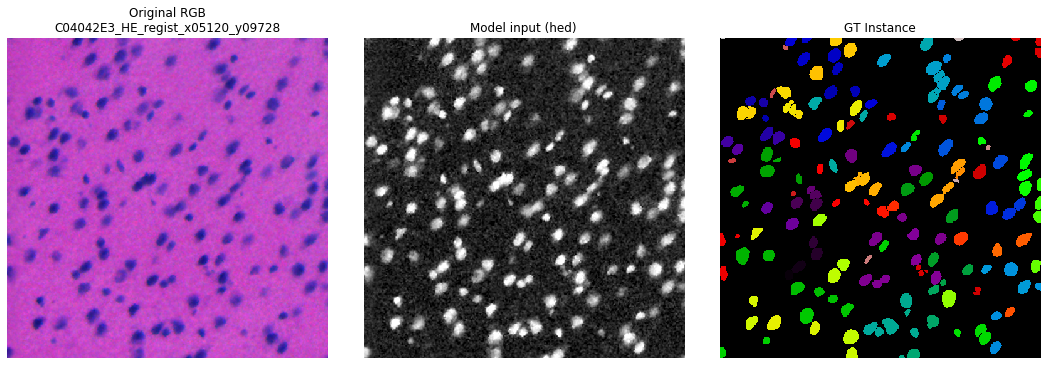

In [8]:
if TUNING_IMAGE_STEM is None:
    tuning_pair = pairs[0]
else:
    stem_to_pair = dict((p["stem"], p) for p in pairs)
    if TUNING_IMAGE_STEM not in stem_to_pair:
        raise KeyError(
            "TUNING_IMAGE_STEM={!r} tidak ditemukan. Contoh stem: {}".format(
                TUNING_IMAGE_STEM,
                list(stem_to_pair.keys())[:5]
            )
        )
    tuning_pair = stem_to_pair[TUNING_IMAGE_STEM]

tuning_image = read_image_any(tuning_pair["image_path"], prefer_memmap=False)
tuning_image_rgb = ensure_rgb_u8(tuning_image)
tuning_gt = load_instance_mask(tuning_pair["mask_path"])

min_area_grid = auto_min_area_grid(
    tuning_gt,
    n=MIN_AREA_GRID_COUNT,
    min_floor=MIN_AREA_GRID_MIN_FLOOR,
)

boost_values = BOOST_GRID if ENABLE_BOOST_GRID else [BOOST_FIXED]
overlap_values = OVERLAP_GRID if ENABLE_OVERLAP_GRID else [OVERLAP_FIXED]

GRID_SEARCH_SPACE = {
    "boost": list(boost_values),
    "overlap": list(overlap_values),
    "increase_factor": list(INCREASE_FACTOR_GRID),
    "min_confidence": list(MIN_CONFIDENCE_GRID),
    "min_area": list(min_area_grid),
}

grid_size = 1
for values in GRID_SEARCH_SPACE.values():
    grid_size *= len(values)

run_config = {
    "image_dir": str(IMAGE_DIR),
    "mask_dir": str(MASK_DIR),
    "output_root": str(OUTPUT_ROOT),
    "cellseg_dir": str(CELLSEG_DIR),
    "model_path": str(MODEL_PATH),
    "tuning_image_stem": tuning_pair["stem"],
    "segment_input_mode": SEGMENT_INPUT_MODE,
    "use_gpu": bool(USE_GPU),
    "grid_search_space": GRID_SEARCH_SPACE,
    "f1_thresholds": list(F1_THRESHOLDS),
    "notes": {
        "default_active_grid": ["increase_factor", "min_confidence", "min_area"],
        "advanced_optional_grid": ["boost", "overlap"],
        "min_area_is_threshold_equivalent": True
    }
}
save_json(RUN_CONFIG_PATH, run_config)

print("Tuning image :", tuning_pair["stem"])
print("Image path   :", tuning_pair["image_path"])
print("Mask path    :", tuning_pair["mask_path"])
print("min_area_grid:", min_area_grid)
print("Total kombinasi grid search:", grid_size)

preview_seg_input, _ = prepare_segment_input(tuning_image_rgb, mode=SEGMENT_INPUT_MODE, boost=boost_values[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(normalize_for_display(tuning_image_rgb))
axes[0].set_title("Original RGB\n{}".format(tuning_pair["stem"]))
axes[0].axis("off")
axes[1].imshow(normalize_for_display(preview_seg_input))
axes[1].set_title("Model input ({})".format(SEGMENT_INPUT_MODE))
axes[1].axis("off")
axes[2].imshow(tuning_gt, cmap="nipy_spectral")
axes[2].set_title("GT Instance")
axes[2].axis("off")
plt.tight_layout()
plt.show()


In [9]:
grid_records = []
best_params = None
best_metrics = None
best_pred_inst = None
best_seg_input = None
best_key = None

total_combinations = (
    len(boost_values)
    * len(overlap_values)
    * len(INCREASE_FACTOR_GRID)
    * len(MIN_CONFIDENCE_GRID)
    * len(min_area_grid)
)

pbar = tqdm(total=total_combinations, desc="Grid search CellSeg")

for boost in boost_values:
    seg_input_u8, _dbg = prepare_segment_input(
        tuning_image_rgb,
        mode=SEGMENT_INPUT_MODE,
        boost=boost,
    )

    for overlap in overlap_values:
        for increase_factor in INCREASE_FACTOR_GRID:
            for min_confidence in MIN_CONFIDENCE_GRID:
                try:
                    model, nrows, ncols, cfg = build_cellseg_model(
                        seg_input_u8.shape,
                        MODEL_PATH,
                        overlap,
                        increase_factor,
                        min_confidence,
                    )
                    crop_labs, crop_scores = infer_cellseg_crops(
                        model,
                        seg_input_u8,
                        nrows,
                        ncols,
                        overlap,
                    )
                    pred_scores = crop_scores[0] if len(crop_scores) == 1 else None

                    for min_area in min_area_grid:
                        pred_inst = stitch_crops_to_full_label(
                            crop_labs,
                            nrows,
                            ncols,
                            overlap,
                            min_area=min_area,
                            quiet=True,
                        )
                        pred_inst = relabel_sequential(pred_inst.astype(np.int32))[0].astype(np.int32)
                        metrics = evaluate_case(tuning_gt, pred_inst, thresholds=F1_THRESHOLDS)

                        record = {
                            "segment_input_mode": SEGMENT_INPUT_MODE,
                            "boost": float(boost),
                            "overlap": int(overlap),
                            "increase_factor": float(increase_factor),
                            "min_confidence": float(min_confidence),
                            "min_area": int(min_area),
                            "Primary_Score_Mean": metrics["Primary_Score_Mean"],
                            "Precision": metrics["Precision"],
                            "Recall": metrics["Recall"],
                            "F1": metrics["F1"],
                            "IoU": metrics["IoU"],
                            "Dice": metrics["Dice"],
                            "AJI": metrics["AJI"],
                            "PQ": metrics["PQ"],
                            "DQ": metrics["DQ"],
                            "SQ": metrics["SQ"],
                            "N_GT": metrics["N_GT"],
                            "N_Pred": metrics["N_Pred"],
                            "Count_Error": metrics["Count_Error"],
                            "status": "ok",
                        }
                        grid_records.append(record)

                        current_key = (
                            record["Primary_Score_Mean"],
                            record["F1"],
                            record["IoU"],
                            record["Precision"],
                            record["Recall"],
                        )
                        if best_key is None or current_key > best_key:
                            best_key = current_key
                            best_params = {
                                "segment_input_mode": SEGMENT_INPUT_MODE,
                                "boost": float(boost),
                                "overlap": int(overlap),
                                "increase_factor": float(increase_factor),
                                "min_confidence": float(min_confidence),
                                "min_area": int(min_area),
                            }
                            best_metrics = dict(metrics)
                            best_pred_inst = pred_inst.copy()
                            best_seg_input = seg_input_u8.copy()

                        pbar.update(1)

                except Exception as exc:
                    for min_area in min_area_grid:
                        record = {
                            "segment_input_mode": SEGMENT_INPUT_MODE,
                            "boost": float(boost),
                            "overlap": int(overlap),
                            "increase_factor": float(increase_factor),
                            "min_confidence": float(min_confidence),
                            "min_area": int(min_area),
                            "Primary_Score_Mean": 0.0,
                            "Precision": 0.0,
                            "Recall": 0.0,
                            "F1": 0.0,
                            "IoU": 0.0,
                            "Dice": 0.0,
                            "AJI": 0.0,
                            "PQ": 0.0,
                            "DQ": 0.0,
                            "SQ": 0.0,
                            "N_GT": int(len(np.unique(tuning_gt[tuning_gt > 0]))),
                            "N_Pred": 0,
                            "Count_Error": -int(len(np.unique(tuning_gt[tuning_gt > 0]))),
                            "status": "error: {}".format(exc),
                        }
                        grid_records.append(record)
                        pbar.update(1)

pbar.close()

grid_df = pd.DataFrame(grid_records).sort_values(
    by=["Primary_Score_Mean", "F1", "IoU", "Precision", "Recall"],
    ascending=False,
).reset_index(drop=True)

if best_params is None or best_metrics is None or best_pred_inst is None:
    raise RuntimeError("Grid search selesai, tetapi tidak ada kombinasi yang berhasil.")

grid_csv = GRID_DIR / "grid_search_results.csv"
grid_xlsx = GRID_DIR / "grid_search_results.xlsx"

grid_df.to_csv(grid_csv, index=False)
try:
    with pd.ExcelWriter(str(grid_xlsx), engine="openpyxl") as writer:
        grid_df.to_excel(writer, sheet_name="grid_search", index=False)
        pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
        pd.DataFrame([best_metrics]).to_excel(writer, sheet_name="best_metrics", index=False)
except Exception as exc:
    print("⚠ Excel grid search tidak tersimpan:", exc)

save_json(GRID_DIR / "best_params.json", best_params)
save_json(GRID_DIR / "best_metrics.json", best_metrics)

display(grid_df.head(10))
print("Best params  :", best_params)
print("Best metrics :", dict((k, best_metrics[k]) for k in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if k in best_metrics))

safe_tiff_write(GRID_DIR / "{}_best_pred_instance.tif".format(tuning_pair["stem"]), best_pred_inst.astype(np.uint32))
save_binary_png(GRID_DIR / "{}_best_pred_binary.png".format(tuning_pair["stem"]), best_pred_inst)
save_case_visuals(tuning_image_rgb, tuning_gt, best_pred_inst, GRID_DIR, "{}_best".format(tuning_pair["stem"]))


Grid search CellSeg:   0%|          | 0/112 [00:00<?, ?it/s]WARNING: Logging before flag parsing goes to stderr.
W0413 06:31:35.988461 140271009433408 deprecation_wrapper.py:119] From /opt/conda/envs/cellseg_py36/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:95: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

W0413 06:31:35.989761 140271009433408 deprecation_wrapper.py:119] From /opt/conda/envs/cellseg_py36/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:98: The name tf.placeholder_with_default is deprecated. Please use tf.compat.v1.placeholder_with_default instead.

W0413 06:31:36.018802 140271009433408 deprecation_wrapper.py:119] From /opt/conda/envs/cellseg_py36/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:102: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0413 06:31:36.019778 140271009433408 deprecation_wrapper.py:119] From /o

,segment_input_mode,boost,overlap,increase_factor,min_confidence,min_area,Primary_Score_Mean,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,N_GT,N_Pred,Count_Error,status
0,hed,0.0,80,0.0,0.7,87,0.864203,0.885859,0.887650,0.886754,0.796548,0.886754,0.690889,0.702200,0.857143,0.819234,182,154,-28,ok
1,hed,0.0,80,0.5,0.7,87,0.864203,0.885859,0.887650,0.886754,0.796548,0.886754,0.690889,0.702200,0.857143,0.819234,182,154,-28,ok
2,hed,0.0,80,0.0,0.7,21,0.864192,0.883315,0.890190,0.886739,0.796524,0.886739,0.691134,0.700989,0.858824,0.816220,182,158,-24,ok
3,hed,0.0,80,0.5,0.7,21,0.864192,0.883315,0.890190,0.886739,0.796524,0.886739,0.691134,0.700989,0.858824,0.816220,182,158,-24,ok
4,hed,0.0,80,1.0,0.7,87,0.857126,0.849854,0.912622,0.880121,0.785907,0.880121,0.698106,0.691675,0.839437,0.823975,182,173,-9,ok
5,hed,0.0,80,1.0,0.7,147,0.856165,0.878172,0.881372,0.879769,0.785346,0.879769,0.694970,0.685370,0.831804,0.823956,182,145,-37,ok
6,hed,0.0,80,0.0,0.3,87,0.855896,0.861324,0.898185,0.879368,0.784708,0.879368,0.684457,0.687107,0.841499,0.816528,182,165,-17,ok
7,hed,0.0,80,0.0,0.5,87,0.855896,0.861324,0.898185,0.879368,0.784708,0.879368,0.684457,0.687107,0.841499,0.816528,182,165,-17,ok
8,hed,0.0,80,0.5,0.3,87,0.855896,0.861324,0.898185,0.879368,0.784708,0.879368,0.684457,0.687107,0.841499,0.816528,182,165,-17,ok
9,hed,0.0,80,0.5,0.5,87,0.855896,0.861324,0.898185,0.879368,0.784708,0.879368,0.684457,0.687107,0.841499,0.816528,182,165,-17,ok


Best params  : {'segment_input_mode': 'hed', 'boost': 0.0, 'overlap': 80, 'increase_factor': 0.0, 'min_confidence': 0.7, 'min_area': 87}
Best metrics : {'Precision': 0.885859, 'Recall': 0.88765, 'F1': 0.886754, 'IoU': 0.796548, 'Dice': 0.886754, 'AJI': 0.690889, 'PQ': 0.7022, 'DQ': 0.857143, 'SQ': 0.819234}


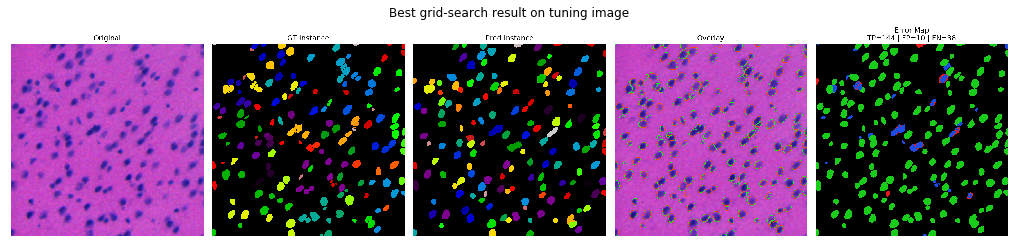

In [10]:
# Tampilkan panel hasil terbaik pada tuning image
best_panel = GRID_DIR / "{}_best_panel.png".format(tuning_pair["stem"])
if best_panel.exists():
    panel_img = io.imread(str(best_panel))
    plt.figure(figsize=(18, 5))
    plt.imshow(panel_img)
    plt.axis("off")
    plt.title("Best grid-search result on tuning image")
    plt.show()
else:
    print("Panel terbaik belum ditemukan:", best_panel)


In [11]:
all_rows = []
failed_cases = []

for pair in tqdm(pairs, total=len(pairs), desc="Inferensi semua gambar"):
    image = read_image_any(pair["image_path"], prefer_memmap=False)
    image_rgb = ensure_rgb_u8(image)
    gt_inst = load_instance_mask(pair["mask_path"])

    case_dir = PER_IMAGE_DIR / pair["stem"]\
    case_dir.mkdir(parents=True, exist_ok=True)

    try:
        out = run_cellseg_once(
            img_rgb_u8=image_rgb,
            mode=best_params["segment_input_mode"],
            boost=best_params["boost"],
            overlap=best_params["overlap"],
            increase_factor=best_params["increase_factor"],
            min_confidence=best_params["min_confidence"],
            min_area=best_params["min_area"],
        )

        pred_inst = relabel_sequential(out["full_label"].astype(np.int32))[0].astype(np.int32)
        metrics = evaluate_case(gt_inst, pred_inst, thresholds=F1_THRESHOLDS)
        metrics.update({
            "image_id": pair["stem"],
            "image_path": str(pair["image_path"]),
            "mask_path": str(pair["mask_path"]),
            "segment_input_mode": best_params["segment_input_mode"],
            "boost": float(best_params["boost"]),
            "overlap": int(best_params["overlap"]),
            "increase_factor": float(best_params["increase_factor"]),
            "min_confidence": float(best_params["min_confidence"]),
            "min_area": int(best_params["min_area"]),
            "nrows": int(out["nrows"]),
            "ncols": int(out["ncols"]),
        })
        all_rows.append(metrics)

        safe_tiff_write(case_dir / "{}_pred_instance.tif".format(pair["stem"]), pred_inst.astype(np.uint32))
        save_binary_png(case_dir / "{}_pred_binary.png".format(pair["stem"]), pred_inst)
        pd.DataFrame([metrics]).to_csv(case_dir / "{}_metrics.csv".format(pair["stem"]), index=False)
        save_json(case_dir / "{}_metrics.json".format(pair["stem"]), metrics)
        save_case_visuals(image_rgb, gt_inst, pred_inst, case_dir, pair["stem"])

    except Exception as exc:
        failed_cases.append({
            "image_id": pair["stem"],
            "image_path": str(pair["image_path"]),
            "mask_path": str(pair["mask_path"]),
            "error": str(exc),
        })

metrics_df = pd.DataFrame(all_rows)
failed_df = pd.DataFrame(failed_cases)

print("Selesai inferensi.")
print("Berhasil :", len(metrics_df))
print("Gagal    :", len(failed_df))
if not failed_df.empty:
    display(failed_df)


Inferensi semua gambar: 100%|██████████| 30/30 [43:16<00:00, 86.56s/it] 

Selesai inferensi.
Berhasil : 30
Gagal    : 0


In [12]:
if metrics_df.empty:
    raise RuntimeError("Tidak ada hasil inferensi yang berhasil, sehingga tidak bisa dibuat rekap.")

id_cols = ["image_id", "image_path", "mask_path"]
param_cols = ["segment_input_mode", "boost", "overlap", "increase_factor", "min_confidence", "min_area", "nrows", "ncols"]
primary_cols = [
    "Precision", "Recall", "F1", "IoU", "Dice",
    "AJI", "PQ", "DQ", "SQ",
    "Primary_Score_Mean",
    "N_GT", "N_Pred", "Count_Error", "Abs_Count_Error",
    "Rel_Count_Err", "Over_Seg_Rate", "Under_Seg_Rate",
    "Specificity", "MCC",
]
threshold_cols = sorted([c for c in metrics_df.columns if c.startswith("F1@")], key=lambda x: float(x.split("@")[1]))
other_cols = [c for c in metrics_df.columns if c not in id_cols + param_cols + primary_cols + threshold_cols]
ordered_cols = [c for c in id_cols + param_cols + primary_cols + threshold_cols + other_cols if c in metrics_df.columns]

metrics_df = metrics_df[ordered_cols].sort_values("image_id").reset_index(drop=True)

numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()
mean_row = metrics_df[numeric_cols].mean().to_dict()
std_row = metrics_df[numeric_cols].std(ddof=1).fillna(0).to_dict()

mean_df = pd.DataFrame([mean_row])
mean_df.insert(0, "stat", "mean")

std_df = pd.DataFrame([std_row])
std_df.insert(0, "stat", "std")

aggregate_df = pd.concat([mean_df, std_df], ignore_index=True)

per_image_csv = SUMMARY_DIR / "per_image_metrics.csv"
aggregate_csv = SUMMARY_DIR / "aggregate_mean_std.csv"
failed_csv = SUMMARY_DIR / "failed_cases.csv"

metrics_df.to_csv(per_image_csv, index=False)
aggregate_df.to_csv(aggregate_csv, index=False)
failed_df.to_csv(failed_csv, index=False)

per_image_xlsx = SUMMARY_DIR / "per_image_metrics.xlsx"
aggregate_xlsx = SUMMARY_DIR / "aggregate_mean_std.xlsx"

try:
    with pd.ExcelWriter(str(per_image_xlsx), engine="openpyxl") as writer:
        metrics_df.to_excel(writer, sheet_name="per_image_metrics", index=False)
except Exception as exc:
    print("⚠ Excel per-image tidak tersimpan:", exc)

try:
    with pd.ExcelWriter(str(aggregate_xlsx), engine="openpyxl") as writer:
        aggregate_df.to_excel(writer, sheet_name="mean_std", index=False)
        mean_df.to_excel(writer, sheet_name="mean_only", index=False)
        std_df.to_excel(writer, sheet_name="std_only", index=False)
        pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
        pd.DataFrame([best_metrics]).to_excel(writer, sheet_name="best_metrics_tuning", index=False)
except Exception as exc:
    print("⚠ Excel aggregate tidak tersimpan:", exc)

display(metrics_df.head())
display(aggregate_df)
print("CSV/Excel tersimpan di:", SUMMARY_DIR)


,image_id,image_path,mask_path,segment_input_mode,boost,overlap,increase_factor,min_confidence,min_area,nrows,ncols,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Specificity,MCC,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,hed,0.0,80,0.0,0.7,87,1,1,0.885859,0.887650,0.886754,0.796548,0.886754,0.690889,0.702200,0.857143,0.819234,0.864203,182,154,-28,28,-0.153846,0.054945,0.208791,0.977852,0.864798,0.892857,0.857143,0.827381,0.785714,0.619048,0.089286,37750,4864,4778,214752,144,10,38,233.670330,114.967368,241.5,0.944110,0.698766,16.590693,276.714286,104.561714,282.5,0.908058,0.672643,18.433179,43.043956,10.405654,41.0,0.036052,0.026123,1.842486
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,hed,0.0,80,0.0,0.7,87,1,1,0.846081,0.888334,0.866692,0.764746,0.866692,0.578505,0.600785,0.755700,0.795004,0.841463,178,129,-49,49,-0.275281,0.073034,0.348315,0.979887,0.849966,0.807818,0.755700,0.703583,0.657980,0.449511,0.052117,25775,4689,3240,228440,116,13,62,163.005618,101.426815,149.5,0.937847,0.695553,13.662923,236.155039,102.743487,227.0,0.932359,0.645531,16.950444,73.149421,1.316672,77.5,0.005488,0.050022,3.287521
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,hed,0.0,80,0.0,0.7,87,1,1,0.854032,0.872063,0.862953,0.758942,0.862953,0.528897,0.561625,0.707424,0.793902,0.836998,130,99,-31,31,-0.238462,0.138462,0.376923,0.986776,0.850711,0.803493,0.707424,0.628821,0.585153,0.436681,0.069869,18629,3184,2733,237598,81,18,49,164.323077,94.026282,147.0,0.903994,0.708012,13.865965,220.333333,121.559147,180.0,0.924987,0.627366,16.247477,56.010256,27.532865,33.0,0.020993,0.080646,2.381512
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,hed,0.0,80,0.0,0.7,87,1,1,0.935665,0.803783,0.864724,0.761687,0.864724,0.634145,0.628687,0.797297,0.788523,0.841465,171,125,-46,46,-0.269006,0.040936,0.309942,0.988452,0.842446,0.844595,0.797297,0.736486,0.689189,0.459459,0.033784,36417,2504,8890,214333,118,7,53,264.953216,193.113118,209.0,0.920059,0.664133,17.116045,311.368000,163.444549,281.0,0.921300,0.616373,19.288938,46.414784,29.668569,72.0,0.001241,0.047760,2.172893
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,hed,0.0,80,0.0,0.7,87,1,1,0.846367,0.848260,0.847313,0.735076,0.847313,0.636966,0.650444,0.819113,0.794083,0.819254,162,131,-31,31,-0.191358,0.067901,0.259259,0.977761,0.825233,0.860068,0.819113,0.784983,0.723549,0.423208,0.034130,28063,5094,5020,223967,120,11,42,204.216049,122.428196,174.5,0.925027,0.658010,15.375872,253.106870,123.405201,209.0,0.929406,0.629408,17.467867,48.890821,0.977005,34.5,0.004379,0.028602,2.091995


,stat,boost,overlap,increase_factor,min_confidence,min_area,nrows,ncols,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Specificity,MCC,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,mean,0.0,80.0,0.0,7.000000e-01,87.0,1.0,1.0,0.866339,0.849123,0.856698,0.749951,0.856698,0.614340,0.628000,0.790642,0.794172,0.830528,166.966667,128.833333,-38.133333,38.133333,-0.225338,0.072178,0.297515,0.982464,0.83787,0.837421,0.790642,0.745655,0.676876,0.459874,0.052844,27443.333333,4021.200000,4909.833333,225769.633333,117.400000,11.433333,49.566667,192.743556,116.010269,173.6000,0.929172,0.674580,14.885904,243.271425,114.609804,220.433333,0.930804,0.62866,17.142886,50.527869,15.214776,46.833333,0.010714,0.045920,2.256982
1,std,0.0,0.0,0.0,3.387608e-16,0.0,0.0,0.0,0.041547,0.030419,0.022656,0.033012,0.022656,0.057944,0.041921,0.049410,0.011349,0.025021,32.958159,23.882014,13.996880,13.996880,0.053271,0.029927,0.060527,0.004128,0.02125,0.040299,0.049410,0.056809,0.054543,0.059872,0.021162,6643.801240,914.038911,1721.499088,8138.725353,24.657097,3.645340,14.639774,28.210037,21.631974,25.8545,0.012868,0.018798,1.081063,25.628221,21.621191,30.811085,0.010768,0.01720,0.874677,15.038173,13.172895,19.057234,0.008902,0.015454,0.598687


CSV/Excel tersimpan di: /data/work/Inference/CellSeg_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik


Plot ringkasan yang tersimpan:
 - /data/work/Inference/CellSeg_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/boxplot_metrics.png
 - /data/work/Inference/CellSeg_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/mean_metrics_bar.png
 - /data/work/Inference/CellSeg_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/object_f1_threshold_curve.png
 - /data/work/Inference/CellSeg_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/cell_count_scatter.png
 - /data/work/Inference/CellSeg_Clean_GridSearch_V2/03_ringkasan_rata_rata_metrik/morphology_summary.png


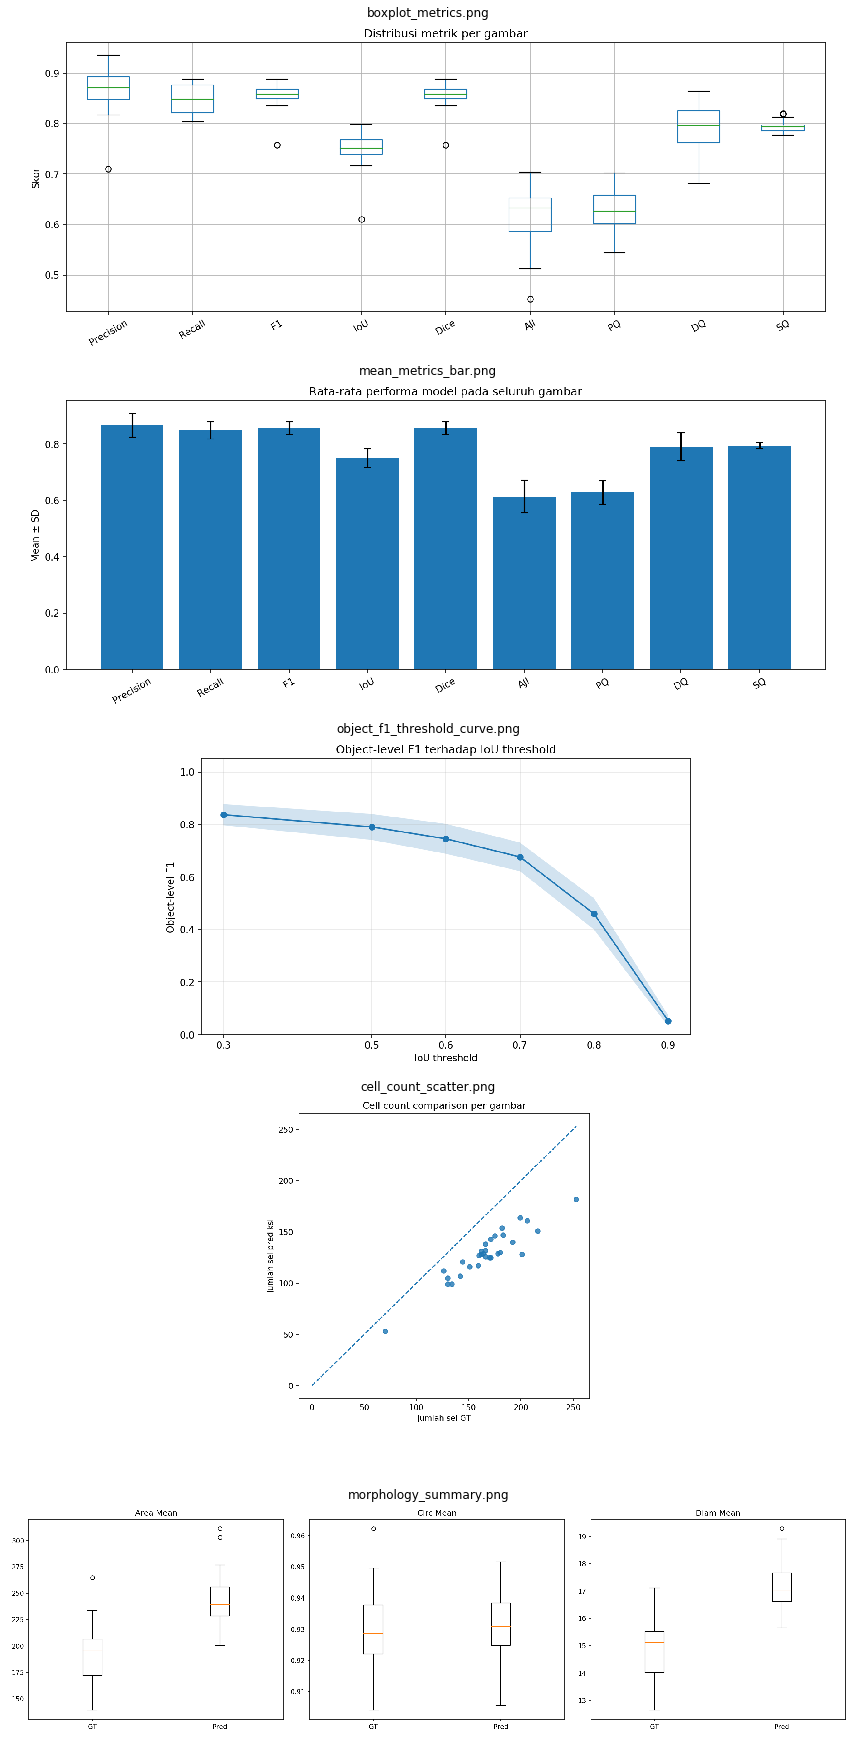

In [ ]:
plot_metric_boxplots(metrics_df, SUMMARY_DIR / "boxplot_metrics.png")
plot_metric_means(metrics_df, SUMMARY_DIR / "mean_metrics_bar.png")
plot_object_f1_curve(metrics_df, SUMMARY_DIR / "object_f1_threshold_curve.png")
plot_cell_count_scatter(metrics_df, SUMMARY_DIR / "cell_count_scatter.png")
plot_morphology_summary(metrics_df, SUMMARY_DIR / "morphology_summary.png")

summary_preview_paths = [
    SUMMARY_DIR / "boxplot_metrics.png",
    SUMMARY_DIR / "mean_metrics_bar.png",
    SUMMARY_DIR / "object_f1_threshold_curve.png",
    SUMMARY_DIR / "cell_count_scatter.png",
    SUMMARY_DIR / "morphology_summary.png",
]

existing = [p for p in summary_preview_paths if p.exists()]
print("Plot ringkasan yang tersimpan:")
for p in existing:
    print(" -", p)

if existing:
    fig, axes = plt.subplots(len(existing), 1, figsize=(12, 5 * max(len(existing), 1)))
    if len(existing) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, existing):
        ax.imshow(io.imread(str(img_path)))
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
